In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# Load preprocessed data
X_train = np.load('../data/X_train.npy')
X_test  = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_test  = np.load('../data/y_test.npy')

feature_names = pd.read_csv('../data/feature_names.csv').iloc[:, 0].tolist()

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Matplotlib is building the font cache; this may take a moment.


Train shape: (12740, 12)
Test shape:  (2000, 12)


In [2]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_preds  = rf.predict(X_test)
rf_probs  = rf.predict_proba(X_test)[:, 1]

print("✅ Random Forest trained!")
print("Accuracy:", round(accuracy_score(y_test, rf_preds) * 100, 2), "%")
print("ROC-AUC: ", round(roc_auc_score(y_test, rf_probs), 4))

✅ Random Forest trained!
Accuracy: 82.5 %
ROC-AUC:  0.8549


In [3]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

print("✅ XGBoost trained!")
print("Accuracy:", round(accuracy_score(y_test, xgb_preds) * 100, 2), "%")
print("ROC-AUC: ", round(roc_auc_score(y_test, xgb_probs), 4))

C:\Users\shad1\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:41:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost trained!
Accuracy: 84.25 %
ROC-AUC:  0.8588


In [4]:
results = pd.DataFrame({
    'Model':    ['Random Forest', 'XGBoost'],
    'Accuracy': [
        round(accuracy_score(y_test, rf_preds)  * 100, 2),
        round(accuracy_score(y_test, xgb_preds) * 100, 2)
    ],
    'ROC-AUC':  [
        round(roc_auc_score(y_test, rf_probs),  4),
        round(roc_auc_score(y_test, xgb_probs), 4)
    ]
})

print(results.to_string(index=False))

        Model  Accuracy  ROC-AUC
Random Forest     82.50   0.8549
      XGBoost     84.25   0.8588


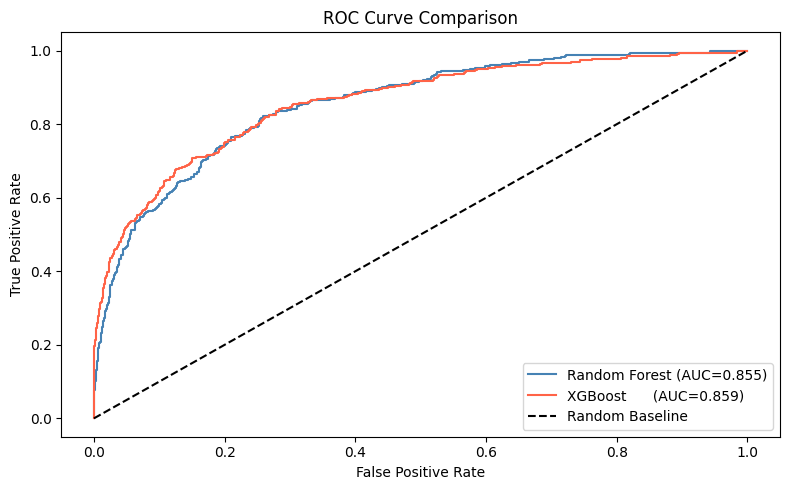

In [5]:
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8, 5))
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC={round(roc_auc_score(y_test, rf_probs), 3)})',  color='steelblue')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost      (AUC={round(roc_auc_score(y_test, xgb_probs), 3)})', color='tomato')
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/roc_curve.png', dpi=150)
plt.show()

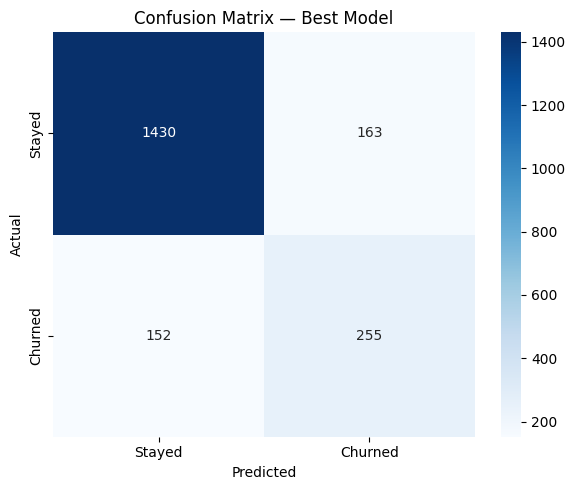


Classification Report:

              precision    recall  f1-score   support

      Stayed       0.90      0.90      0.90      1593
     Churned       0.61      0.63      0.62       407

    accuracy                           0.84      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.84      0.84      0.84      2000



In [6]:
# Use whichever had higher ROC-AUC
best_preds = xgb_preds  # swap to rf_preds if RF wins

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix — Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../screenshots/confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, best_preds, target_names=['Stayed', 'Churned']))

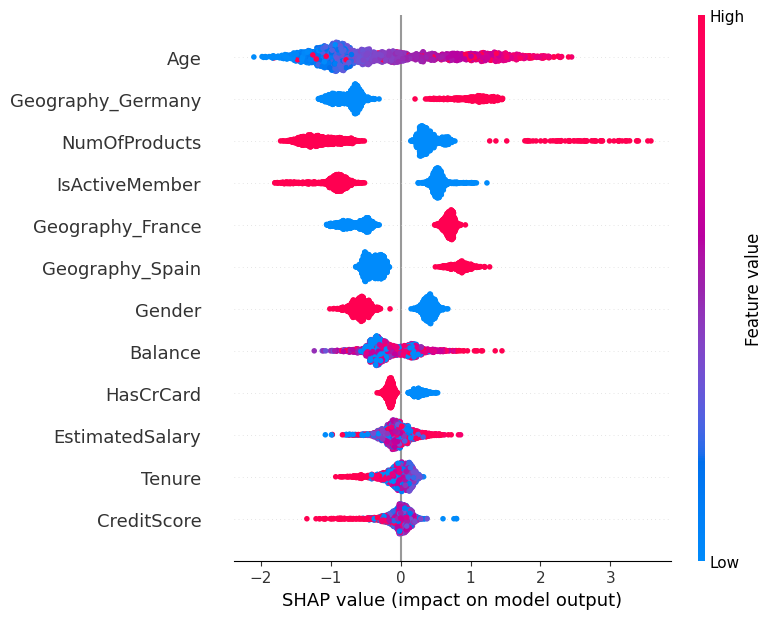

In [7]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names,
                  show=False)
plt.tight_layout()
plt.savefig('../screenshots/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Save best model
with open('../data/best_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)   # swap to rf if RF wins

# ── Power BI Export ──────────────────────────────────────────
with open('../data/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

raw_test = pd.read_csv('../data/churn_cleaned.csv')

# Encode same as preprocessing
raw_test['Gender'] = raw_test['Gender'].map({'Male': 1, 'Female': 0})
raw_test = pd.get_dummies(raw_test, columns=['Geography'], drop_first=False)

X_raw = raw_test.drop(columns=['Exited'])
X_scaled = scaler.transform(X_raw)

probs  = xgb.predict_proba(X_scaled)[:, 1]
preds  = xgb.predict(X_scaled)

export_df = raw_test.copy()
export_df['Churn_Probability'] = probs.round(4)
export_df['Churn_Predicted']   = preds
export_df['Churn_Actual']      = raw_test['Exited'].values
export_df['Risk_Segment'] = pd.cut(probs,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

export_df.to_csv('../data/powerbi_export.csv', index=False)
print("✅ Model saved!")
print("✅ Power BI export ready → data/powerbi_export.csv")
print("\nExport shape:", export_df.shape)
print("\nRisk Segment Distribution:\n", export_df['Risk_Segment'].value_counts())

✅ Model saved!
✅ Power BI export ready → data/powerbi_export.csv

Export shape: (10000, 17)

Risk Segment Distribution:
 Risk_Segment
Low Risk       6906
High Risk      1677
Medium Risk    1417
Name: count, dtype: int64
